In [27]:

import ast

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from kagglehub import KaggleDatasetAdapter
from sklearn.metrics import ConfusionMatrixDisplay,cohen_kappa_score
import numpy as np

import sys, os
sys.path.insert(0, os.path.abspath('..'))

from intelli_e_reader.plot_utils import plot_pos_distribution
from intelli_e_reader.plot_utils import compare_cefr_sources
from intelli_e_reader.data_utils import build_efllex_cefr, extend_family1_with_efllex,build_family1_word_cefr



%load_ext autoreload
%autoreload 2
sns.set_theme()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Family 1: "What CEFR level is this word?"
  
* Source A (scraped): english_profile_scrape.csv → modified_scrap_data.csv

* Source B (teachers): word_pos_modified_data.csv 

In [28]:
family1_word_cefr = build_family1_word_cefr()
print(family1_word_cefr.shape)
family1_word_cefr.head()


(9654, 5)


,word,pos,cefr_int,cefr,source
0,cattle,NA,3,B,english_profile
1,clothes,NA,1,A,english_profile
2,albeit,NA,6,C,english_profile
3,and,NA,1,A,english_profile
5,because,NA,1,A,english_profile


In [29]:
efllex_cefr = build_efllex_cefr()
family1_extended = extend_family1_with_efllex(family1_word_cefr, efllex_cefr)

print(f"before: {family1_word_cefr.shape[0]} rows, {family1_word_cefr['word'].nunique()} unique words")
print(f"after:  {family1_extended.shape[0]} rows, {family1_extended['word'].nunique()} unique words")
family1_extended['source'].value_counts()


before: 9654 rows, 8434 unique words
after:  18585 rows, 16546 unique words


source
efllex             8931
english_profile    7432
teacher_survey     2222
Name: count, dtype: int64

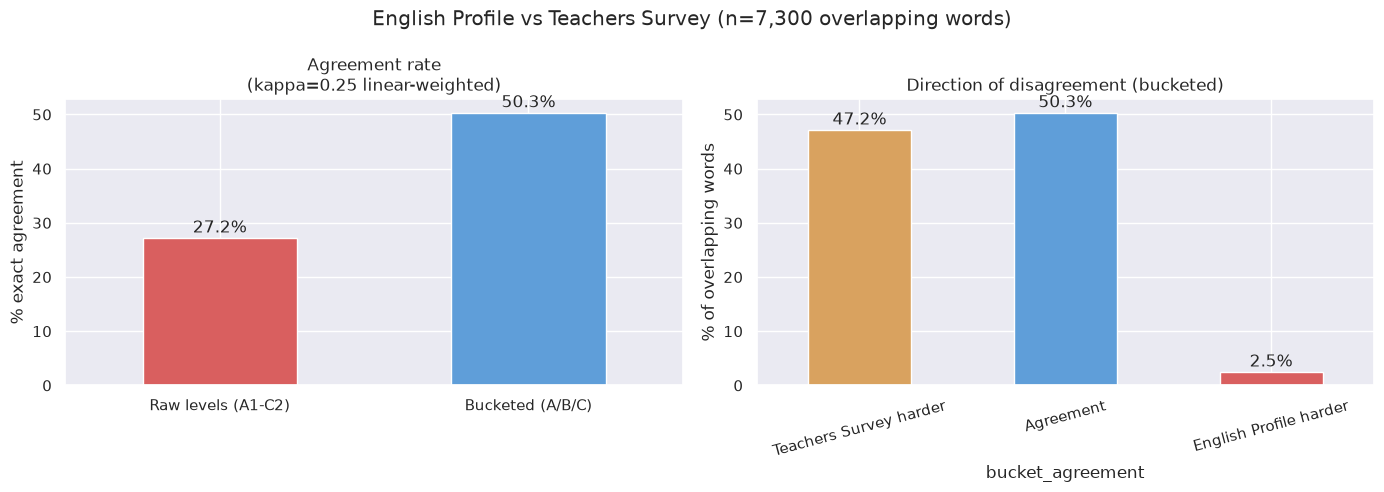

{'n_overlap': 7300,
 'exact_match_raw': np.float64(0.2723287671232877),
 'exact_match_bucketed': np.float64(0.5034246575342466),
 'kappa_raw_unweighted': 0.11135659170273315,
 'kappa_raw_linear': 0.2471960304434181,
 'kappa_bucketed': 0.2142575444192052,
 'mean_level_diff': np.float64(1.1409589041095891),
 'median_level_diff': np.float64(1.0)}

In [30]:
cefr_int_map = {1: "a1", 2: "a2", 3: "b1", 4: "b2", 5: "c1", 6: "c2"}

source_scraped_df = pd.read_csv('../data/raw/english_profile_cleaned.csv', keep_default_na=False, na_values=['']).assign(source='english_profile')
source_scraped_df['cefr'] = source_scraped_df['cefr_int'].map(cefr_int_map)

source_teachers_df = pd.read_csv('../data/raw/teacher_survey_avg_scores.csv').rename(
    columns={'Word': 'word', 'PoS': 'pos', 'Teachers Avg': 'cefr_int'})
source_teachers_df = source_teachers_df.dropna(subset=['cefr_int'])
source_teachers_df['word'] = source_teachers_df['word'].str.lower().str.strip()
source_teachers_df = source_teachers_df.drop_duplicates(subset=['word', 'pos'], keep='first')
source_teachers_df['cefr_int'] = source_teachers_df['cefr_int'].round().astype(int)
source_teachers_df['cefr'] = source_teachers_df['cefr_int'].map(cefr_int_map)

_, stats = compare_cefr_sources(source_scraped_df, source_teachers_df, name_a="English Profile", name_b="Teachers Survey")
stats


In [31]:
print(f"Total unique words and associated POS: {family1_word_cefr.shape[0]} words")
print(f"Total unique POS tags: {family1_word_cefr['pos'].nunique()} types")

Total unique words and associated POS: 9654 words
Total unique POS tags: 14 types


In [32]:
family1_word_cefr["pos"].value_counts()

pos
NOUN       4969
ADJ        2002
VERB       1584
ADV         622
NA          131
ADP          93
PRONOUN      61
DET          50
PHR          42
PRON         37
CONJ         30
EXC          20
MVB          10
AVB           3
Name: count, dtype: int64

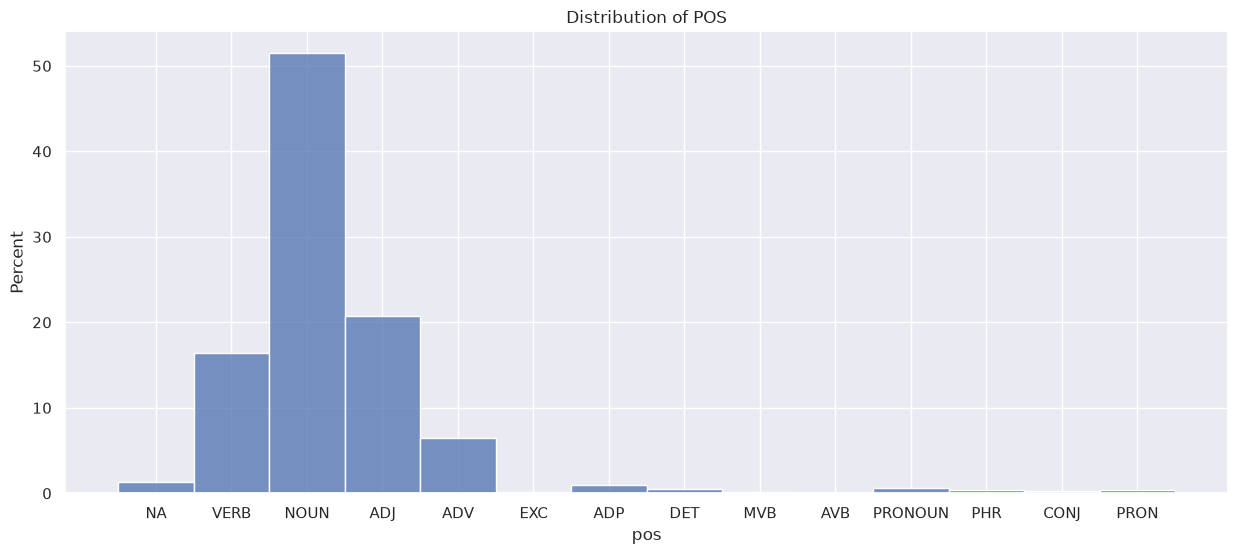

In [33]:
plot_pos_distribution(df=family1_word_cefr)

### Clean data and balance the distribution

In [34]:
# 1: Combine similar POS e.g., PRON == PRONOUN
tags_to_merge = {
    'MVB': 'VERB',
    'AVB': 'VERB',
    'PRONOUN': 'PRON'
}

family1_word_cefr["pos"] = family1_word_cefr["pos"].replace(tags_to_merge)
family1_word_cefr['pos'].value_counts()

# 2:  

pos
NOUN    4969
ADJ     2002
VERB    1597
ADV      622
NA       131
PRON      98
ADP       93
DET       50
PHR       42
CONJ      30
EXC       20
Name: count, dtype: int64

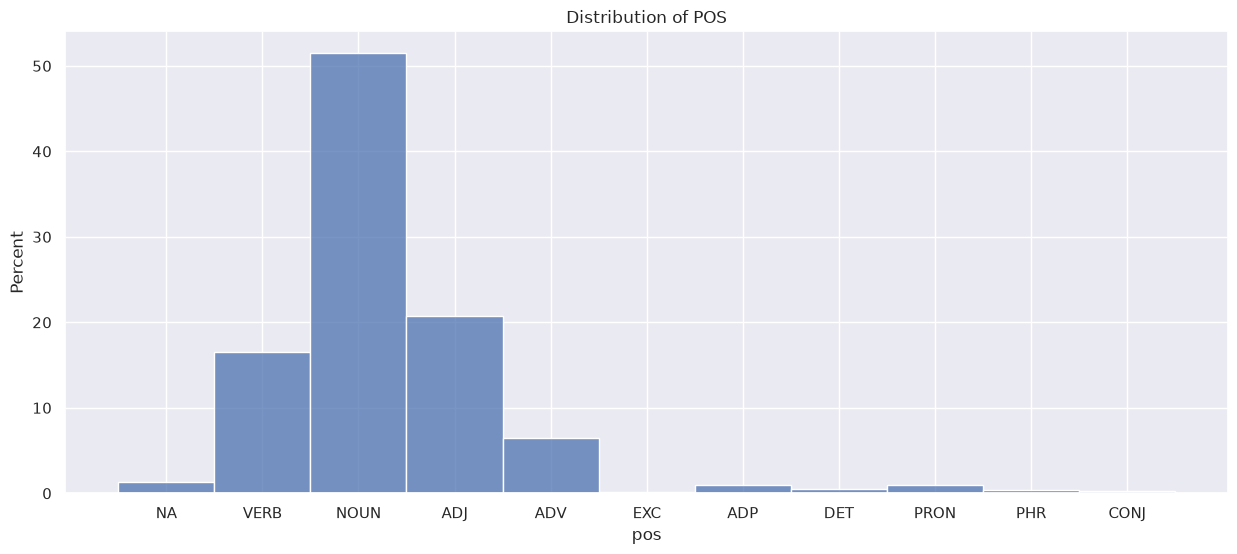

In [35]:
plot_pos_distribution(df = family1_word_cefr)

In [36]:
# Penn Treebank Tags

ptb_to_universal = {
    'NN': 'NOUN', 'JJ': 'ADJ', 'VB': 'VERB', 'RB': 'ADV',
    'CD': 'NUM', 'IN': 'ADP', 'UH': 'EXC', 'PRP': 'PRON',
    'PRP$': 'PRON', 'DT': 'DET', 'RP': 'PART', 'MD': 'VERB',
    'PR': 'PRON', 'CC': 'CONJ', 'WP': 'PRON', 'WP$': 'PRON',
    'WRB': 'ADV', 'PDT': 'DET', 'WDT': 'DET', 'TO': 'ADP',
    'EX': 'PRON', 'FW': 'X', 'XX': 'X', 'RH': 'X'
}

In [37]:
# 2: Use EFLLex with NLP4J parts of speech [https://cental.uclouvain.be/cefrlex/efllex/]

efllex_df = pd.read_csv('../data/raw/EFLLex.tsv',sep='\t')


drop_list = ['word','tag','total_freq@total','nb_doc@total','face2face@total']
level_colums = efllex_df.columns.difference(drop_list)

efllex_df['cefr'] = efllex_df[level_colums].idxmax(axis=1).str.rsplit('@').str[-1].str.strip()

feature_list = ['word','tag','total_freq@total','cefr']
efllex_df = efllex_df[feature_list]
efllex_df['tag'] = efllex_df['tag'].str.strip()
efllex_df = efllex_df.rename(columns={
    'total_freq@total': 'total_freq',
    'tag':'pos'
})

efllex_df = efllex_df.sort_values(by='pos',ascending=False,key=lambda x: x.map(efllex_df['pos'].value_counts()))
efllex_df['pos'] = efllex_df['pos'].replace(ptb_to_universal)

print(f"Shape of the dataset = {efllex_df.shape}")
efllex_df.head()

Shape of the dataset = (15281, 4)


/tmp/ipykernel_17268/4243894809.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  efllex_df['cefr'] = efllex_df[level_colums].idxmax(axis=1).str.rsplit('@').str[-1].str.strip()


,word,pos,total_freq,cefr
15280,zoo,NOUN,2.7832,b1
0,'50s,NOUN,1.2813,b1
1,'60s,NOUN,0.8740,a2
2,'70s,NOUN,0.1625,a2
3,'80s,NOUN,0.1625,a2


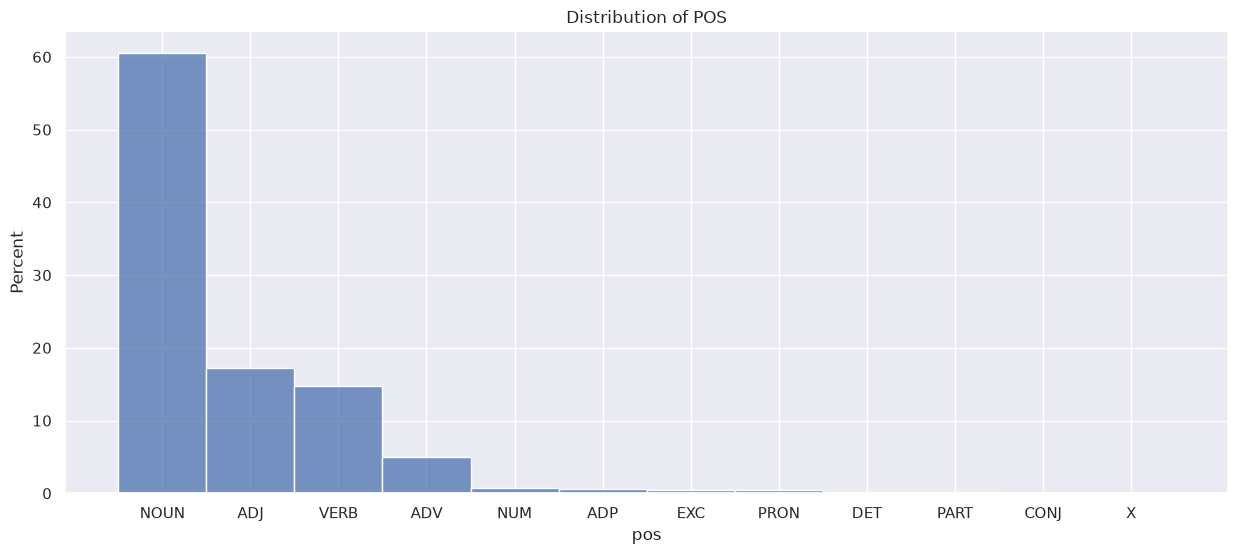

In [38]:
plot_pos_distribution(df = efllex_df)

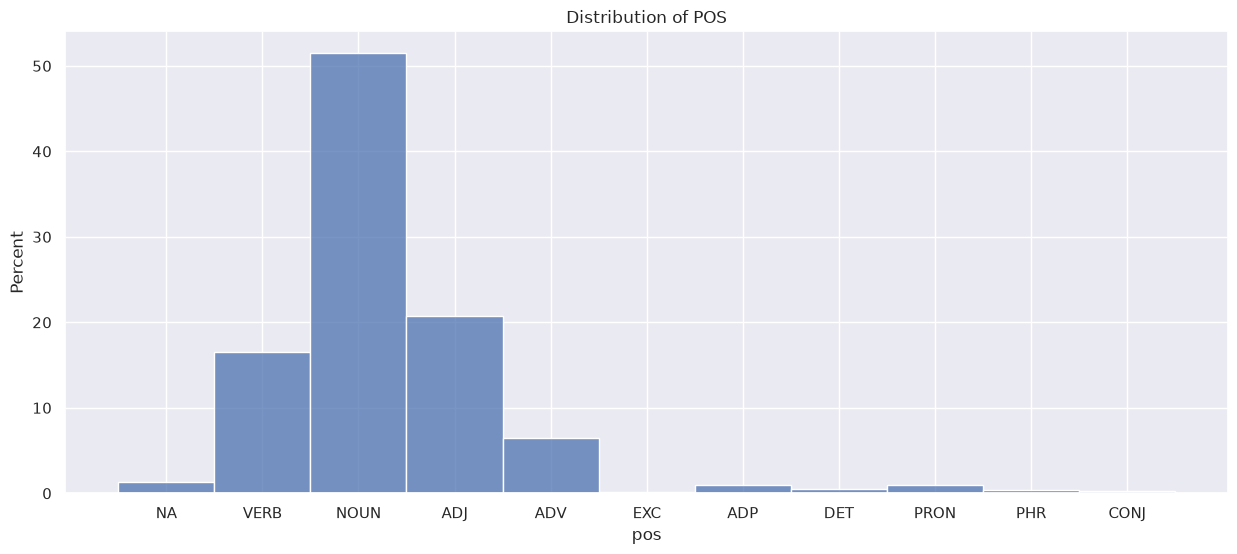

In [39]:
plot_pos_distribution(family1_word_cefr)

In [40]:
# Map back the CEFR int mapping to match the EFLLEX dataset
cefr_int_map = {
    1: "a1",
    2: "a2",
    3: "b1",
    4: "b2",
    5: "c1",
    6: "c2"
}

family1_word_cefr['cefr_int'] = family1_word_cefr['cefr_int'].replace(cefr_int_map)
family1_word_cefr.drop(columns=['cefr'],inplace=True)
family1_word_cefr = family1_word_cefr.rename(columns={
    'cefr_int':'cefr'
})
family1_word_cefr.head()

,word,pos,cefr,source
0,cattle,NA,b1,english_profile
1,clothes,NA,a1,english_profile
2,albeit,NA,c2,english_profile
3,and,NA,a1,english_profile
5,because,NA,a1,english_profile


In [41]:
combined_df = efllex_df.merge(family1_word_cefr,on=['word','pos'],how='inner',suffixes=['_ef','_fam'])
combined_df.shape

(6413, 6)

In [42]:
combined_df.head()

,word,pos,total_freq,cefr_ef,cefr_fam,source
0,zoo,NOUN,2.7832,b1,a1,english_profile
1,year,NOUN,1579.2507,b1,a2,english_profile
2,yellow,NOUN,0.4670,a1,a2,english_profile
3,yacht,NOUN,0.2268,c1,b2,english_profile
4,yard,NOUN,17.9130,c1,b1,english_profile


In [43]:
print(f"Length of our dataset: {(family1_word_cefr['word'].nunique())}")
print(f"Length of EFLLEX dataset: {(efllex_df['word'].nunique())}")
print(f"Length of overalapping dataset: {(combined_df['word'].nunique())}")

print(f"Overlap percent = {(combined_df['word'].nunique()/efllex_df['word'].nunique())*100:.2f}%")

Length of our dataset: 8434
Length of EFLLEX dataset: 13871
Length of overalapping dataset: 5620
Overlap percent = 40.52%


<Figure size 1500x600 with 0 Axes>

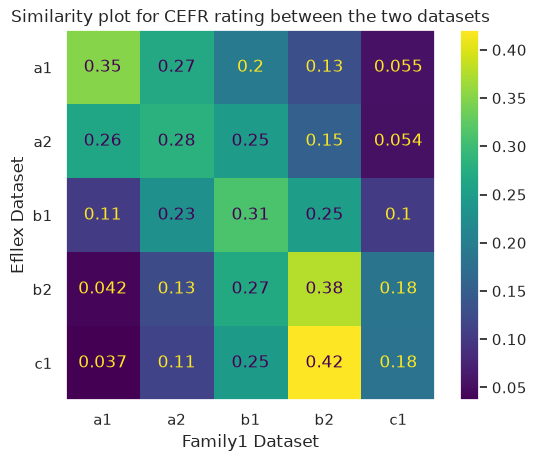

In [44]:
# Find Agreement rate

d1 = combined_df['cefr_ef']
d2 = combined_df['cefr_fam']

plt.figure(figsize=(15,6))
ConfusionMatrixDisplay.from_predictions(d1,d2,normalize='true',labels=['a1','a2','b1','b2','c1'])
plt.grid(False)
plt.title('Similarity plot for CEFR rating between the two datasets')
plt.xlabel('Family1 Dataset')
plt.ylabel('Efllex Dataset')
plt.show()

In [45]:
ordinal_map = {"a1": 1, "a2": 2, "b1": 3, "b2": 4, "c1": 5, "c2": 6}

combined_df["bucket_ef"] = combined_df["cefr_ef"].map(ordinal_map)
combined_df["bucket_fam"] = combined_df["cefr_fam"].map(ordinal_map)
combined_df["level_diff"] = combined_df["bucket_ef"] - combined_df["bucket_fam"]


In [46]:

def condition_agg(row):
    if row['level_diff'] > 0:
        return "EFLLex harder"
    elif row["level_diff"] == 0:
        return "Agreement"
    else:
        return "Our data harder"

combined_df["agreement_bucket"] = combined_df.apply(condition_agg,axis=1)

In [47]:
combined_df.head()

,word,pos,total_freq,cefr_ef,cefr_fam,source,bucket_ef,bucket_fam,level_diff,agreement_bucket
0,zoo,NOUN,2.7832,b1,a1,english_profile,3,1,2,EFLLex harder
1,year,NOUN,1579.2507,b1,a2,english_profile,3,2,1,EFLLex harder
2,yellow,NOUN,0.4670,a1,a2,english_profile,1,2,-1,Our data harder
3,yacht,NOUN,0.2268,c1,b2,english_profile,5,4,1,EFLLex harder
4,yard,NOUN,17.9130,c1,b1,english_profile,5,3,2,EFLLex harder


## Cross-checking our CEFR ratings against an independent source

Our word-level CEFR ratings come from an English Profile scrape + a 3-teacher
survey. To check how reliable these are, we cross-referenced against
**EFLLex** (UCLouvain's CEFRLex project — an independently built,
corpus-derived CEFR lexicon), on the 37.9% of our vocabulary both sources
cover (n=6,023 overlapping word/POS pairs).

**Raw agreement** is weak: only 24.7% exact match at the full A1-C2
granularity, rising to 44.9% once both sources are bucketed to the A/B/C
scale this app actually uses. There's also a real, one-directional bias —
EFLLex rates the same words about half a level harder on average (45% of
overlapping words rated harder by EFLLex vs. 30% rated harder by us).

**Chance-corrected agreement (Cohen's Kappa) tells a more sobering story.**
Both sources lean heavily toward the "B" bucket, so a large share of the raw
44.9% is just two sources independently favoring the same popular category,
not real agreement about specific words. After correcting for this:
- 6-level, linear-weighted kappa: **0.20** (slight/fair boundary)
- Bucketed (A/B/C), unweighted kappa: **0.12** (slight)

Both sit in "barely better than chance" territory on the standard
Landis-Koch scale. Bucketing nearly doubles *raw* agreement, but doesn't
meaningfully improve *chance-corrected* agreement — most of that raw
improvement is inflated by fewer categories, not genuinely better
reliability (though a word-level check shows ~71% of the newly-agreeing
words are real adjacent-level convergence, e.g. "we said B1, EFLLex said
B2" — not just the EFLLex C1-ceiling artifact).

**Takeaway**: neither source can be treated as ground truth over the
other — kappa this low doesn't favor EFLLex just because it's an academic
resource, and it doesn't justify blending the two (averaging assumes
independent, zero-mean noise; we've shown the disagreement is systematic,
not just noise). Our ground-truth CEFR labels carry real, quantifiable
noise, which is part of why the live app collapses to 3 buckets rather
than full A1-C2 — and it's a caveat any model trained on this data should
carry explicitly.


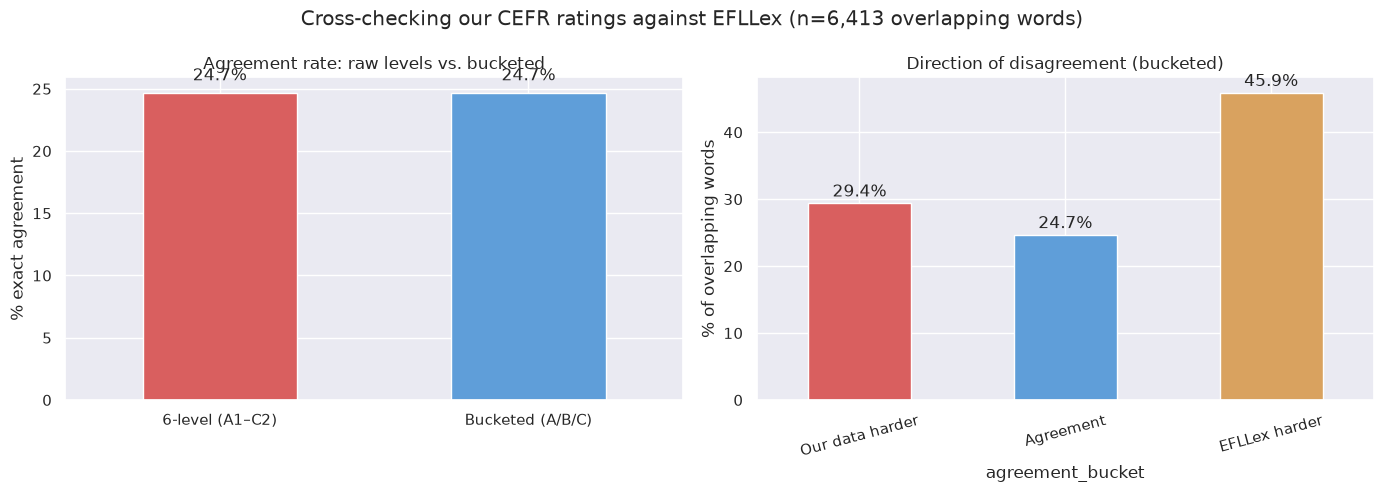

In [48]:
exact6 = (combined_df["level_diff"] == 0).mean()                          # 0.2474 — 6-level exact match
exactb = (combined_df["bucket_ef"] == combined_df["bucket_fam"]).mean()   # 0.4489 — bucketed (A/B/C) exact match

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

match_rates = pd.Series({"6-level (A1–C2)": exact6, "Bucketed (A/B/C)": exactb}) * 100
match_rates.plot(kind="bar", ax=axes[0], color=["#d95f5f", "#5f9ed9"])
axes[0].set_ylabel("% exact agreement")
axes[0].set_title("Agreement rate: raw levels vs. bucketed")
axes[0].set_xticklabels(match_rates.index, rotation=0)
for i, v in enumerate(match_rates):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center")
    
order = ["Our data harder", "Agreement", "EFLLex harder"]
bucket_conditions = [
    combined_df["bucket_ef"] > combined_df["bucket_fam"],
    combined_df["bucket_ef"] == combined_df["bucket_fam"],
    combined_df["bucket_ef"] < combined_df["bucket_fam"],
]
pct = combined_df["agreement_bucket"].value_counts(normalize=True).reindex(order) * 100

pct.plot(kind="bar", ax=axes[1], color=["#d95f5f", "#5f9ed9", "#d9a25f"])
axes[1].set_ylabel("% of overlapping words")
axes[1].set_title("Direction of disagreement (bucketed)")
axes[1].set_xticklabels(order, rotation=15)
for i, v in enumerate(pct):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center")

plt.suptitle("Cross-checking our CEFR ratings against EFLLex (n={:,} overlapping words)".format(len(combined_df)))
plt.tight_layout()
plt.show()



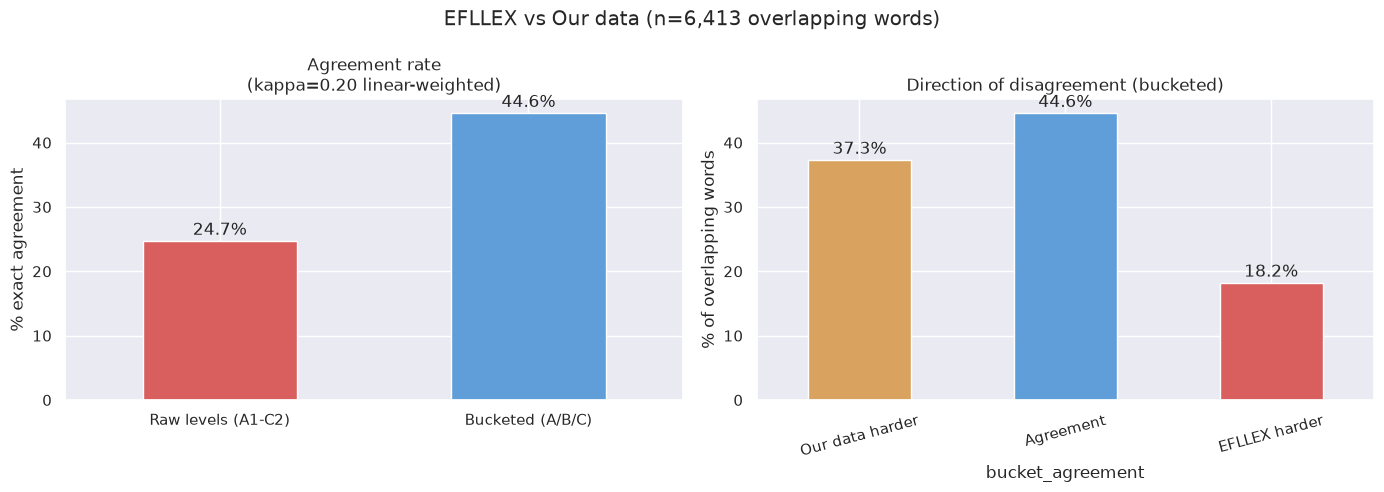

Stats for Family1 vs EFLLEX dataset


{'n_overlap': 6413,
 'exact_match_raw': np.float64(0.2468423514735693),
 'exact_match_bucketed': np.float64(0.4455013254327148),
 'kappa_raw_unweighted': 0.06726300407549357,
 'kappa_raw_linear': 0.19810698082262135,
 'kappa_bucketed': 0.11694126543277272,
 'mean_level_diff': np.float64(0.25651021362856696),
 'median_level_diff': np.float64(0.0)}

In [49]:

combined_df, stats = compare_cefr_sources(
    efllex_df,family1_word_cefr, name_a="EFLLEX", name_b="Our data"
)

print('='*10)
print("Stats for Family1 vs EFLLEX dataset")
stats


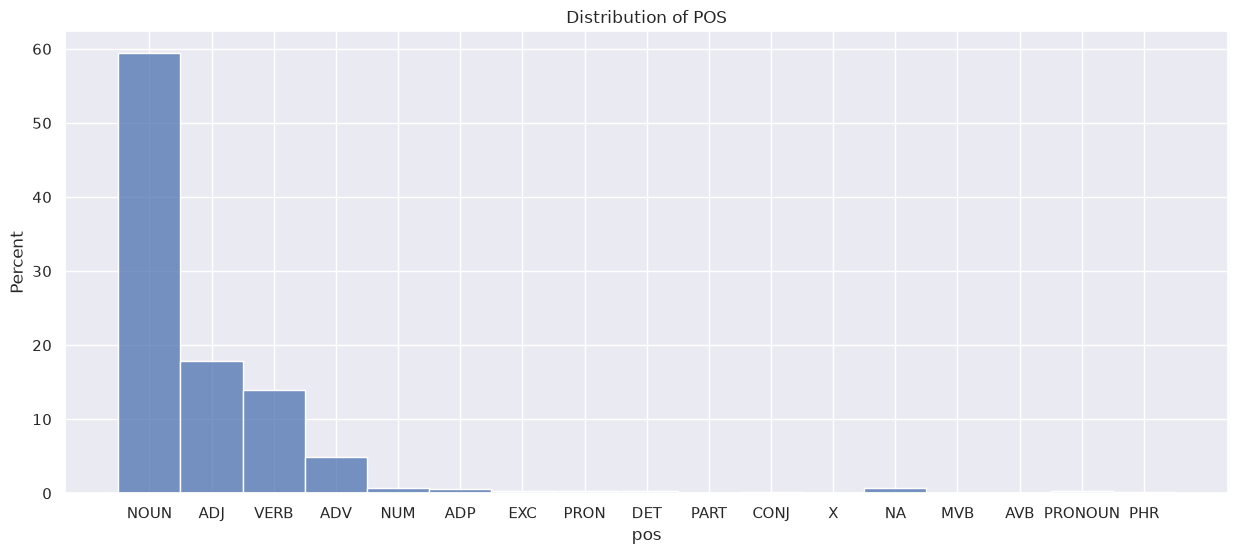

In [50]:
# POS distribution
family1_extended = family1_extended.sort_values(by='pos',ascending=False,key=lambda x: x.map(efllex_df['pos'].value_counts()))
family1_extended['pos'] = family1_extended['pos'].replace(ptb_to_universal)

plot_pos_distribution(family1_extended)

In [51]:
family1_extended['pos'].value_counts(),family1_extended.shape

(pos
 NOUN       11040
 ADJ         3330
 VERB        2585
 ADV          901
 NA           131
 NUM          121
 ADP          117
 EXC           70
 PRON          64
 PRONOUN       61
 DET           52
 PHR           42
 CONJ          38
 PART          17
 MVB           10
 X              3
 AVB            3
 Name: count, dtype: int64,
 (18585, 6))

In [52]:
family1_extended.head()

,word,pos,cefr_int,cefr,source,total_freq
18584,zombie,NOUN,3,B,efllex,0.0314
18544,writing_letter,NOUN,4,B,efllex,0.0555
18545,writing_paper,NOUN,5,C,efllex,0.0717
18546,writing_table,NOUN,5,C,efllex,0.0796
18547,writing_voice,NOUN,4,B,efllex,0.2268


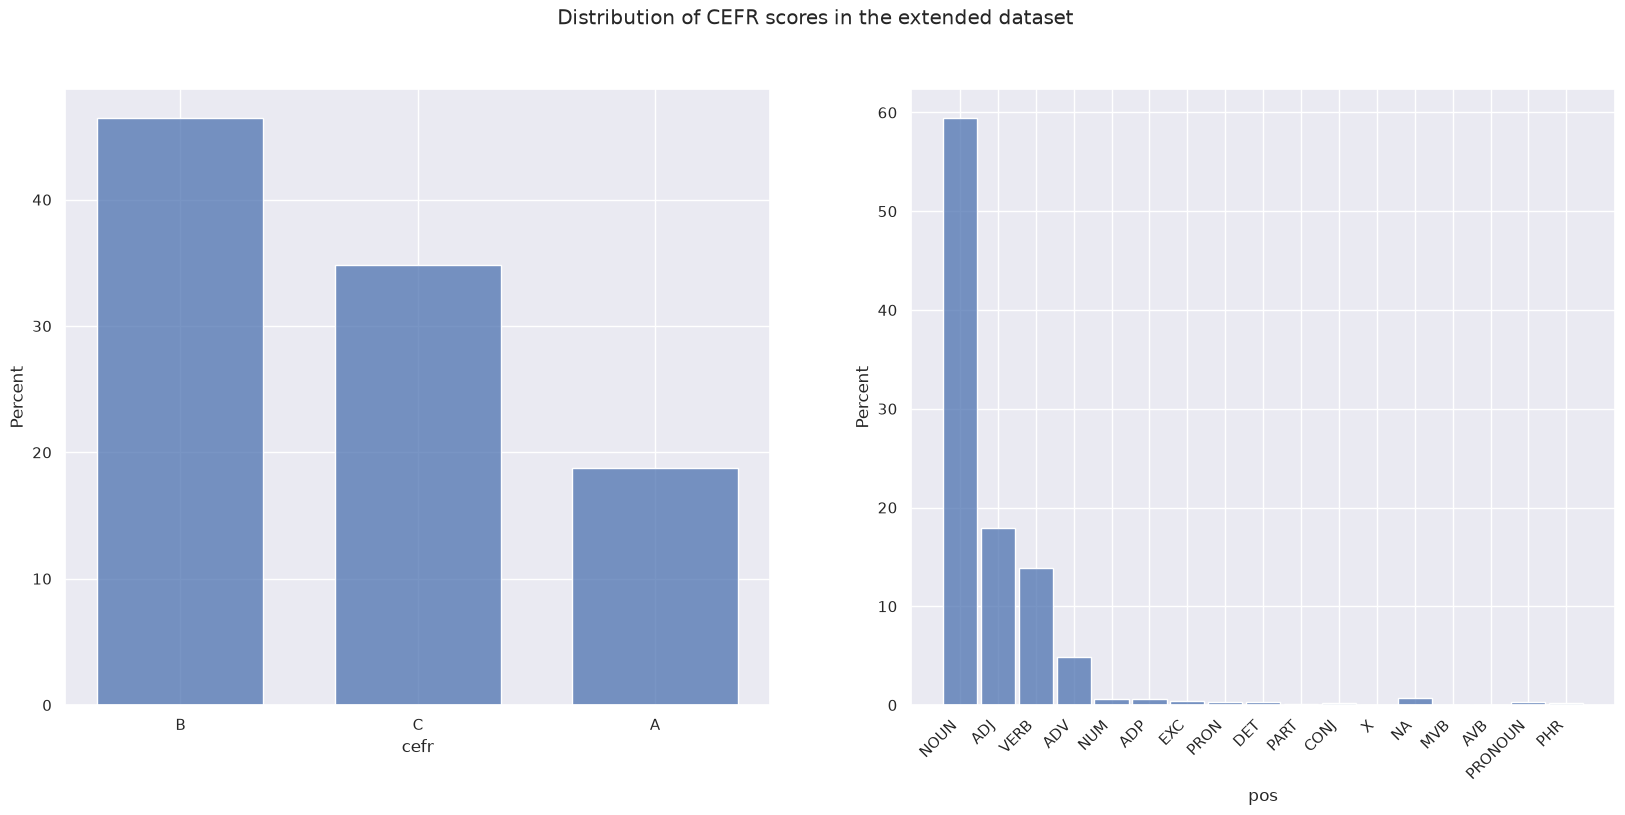

In [80]:
# Distribution of CEFR level across different data sources

_,ax = plt.subplots(ncols=2,nrows=1,figsize=(20,8))

sns.histplot(family1_extended,x='cefr',stat='percent',ax=ax[0],multiple='dodge',shrink=0.7)
sns.histplot(family1_extended,x='pos',stat='percent',ax=ax[1],multiple='dodge',shrink=0.9,)
plt.suptitle('Distribution of CEFR scores in the extended dataset')
plt.xticks(rotation=45,ha='right')
plt.show()

## Family 2: "What are the synonyms for this word?"

* Source A (a synonym-finder scraper)
* Source B (a thesaurus scraper)

In [51]:
import json

with open('../data/raw/pos_acronym_map.json','r') as file:
    acronym_map = json.load(file)  

acronym_map

{'ADJ': 'aj',
 'ADV': 'av',
 'CONJ': 'cj',
 'DET': 'dt',
 'NOUN': 'n',
 'VERB': 'v',
 'PRON': 'pn',
 'ADP': 'pp',
 'nan': 'na'}

In [54]:
source_synonyms_site_scrape = pd.read_csv("../data/raw/synonyms_scrape.csv")
source_thesarus_site_scrape = pd.read_csv("../data/raw/thesaurus_scrape.csv")


source_synonyms_site_scrape = source_synonyms_site_scrape.rename(columns={"Word":"word","Synonyms":"synonym_list"})
source_thesarus_site_scrape = source_thesarus_site_scrape.rename(columns={"Word":"word","Synonyms":"synonym_list"})


source_synonyms_site_scrape["synonym_list"] = source_synonyms_site_scrape["synonym_list"].apply(ast.literal_eval)
source_thesarus_site_scrape["synonym_list"] = source_thesarus_site_scrape["synonym_list"].apply(ast.literal_eval)
source_thesarus_site_scrape[['word','pos']] = source_thesarus_site_scrape['word'].str.rsplit(n=1,pat='_',expand=True)
full_pos_map = {v: k for k, v in acronym_map.items()}
source_thesarus_site_scrape['pos'] = source_thesarus_site_scrape['pos'].map(full_pos_map)

family2_word_synonyms = pd.merge(source_synonyms_site_scrape, source_thesarus_site_scrape, on='word', how='outer', suffixes=('_syn', '_thes'))
family2_word_synonyms.head()

,word,synonym_list_syn,synonym_list_thes,pos
0,AIRMAN,"[aviator, corporal, pilot, flier]",NaN,NaN
1,ANOther,"[other, latest, last, further, a]","[a different person, addition, one more, someo...",NOUN
2,ARTHUR,"[artur, arthure, arturo]",NaN,NaN
3,AWE,"[veneration, admiration, glare, reverence, daz...","[admiration, apprehension, astonishment, const...",NOUN
4,Albert,"[alberto, elbert, alberts, hugh]",NaN,NaN


In [55]:
# combine synonyms list
def combine_lists(row):
    a = row['synonym_list_syn'] if isinstance(row['synonym_list_syn'], list) else []
    b = row['synonym_list_thes'] if isinstance(row['synonym_list_thes'], list) else []
    return a + b

family2_word_synonyms['synonym_list'] = family2_word_synonyms.apply(combine_lists,axis=1)
family2_word_synonyms.head()

,word,synonym_list_syn,synonym_list_thes,pos,synonym_list
0,AIRMAN,"[aviator, corporal, pilot, flier]",NaN,NaN,"[aviator, corporal, pilot, flier]"
1,ANOther,"[other, latest, last, further, a]","[a different person, addition, one more, someo...",NOUN,"[other, latest, last, further, a, a different ..."
2,ARTHUR,"[artur, arthure, arturo]",NaN,NaN,"[artur, arthure, arturo]"
3,AWE,"[veneration, admiration, glare, reverence, daz...","[admiration, apprehension, astonishment, const...",NOUN,"[veneration, admiration, glare, reverence, daz..."
4,Albert,"[alberto, elbert, alberts, hugh]",NaN,NaN,"[alberto, elbert, alberts, hugh]"


In [62]:
# Add synonyms list to combined dataset
synonym_word_pos_df = family1_word_cefr.merge(family2_word_synonyms[['word', 'pos', 'synonym_list']], on=['word', 'pos'], how='left')
synonym_word_pos_df.head()

,word,pos,cefr_int,cefr,source,synonym_list
0,cattle,NA,3,B,english_profile,NaN
1,clothes,NA,1,A,english_profile,NaN
2,albeit,NA,6,C,english_profile,NaN
3,and,NA,1,A,english_profile,NaN
4,because,NA,1,A,english_profile,NaN


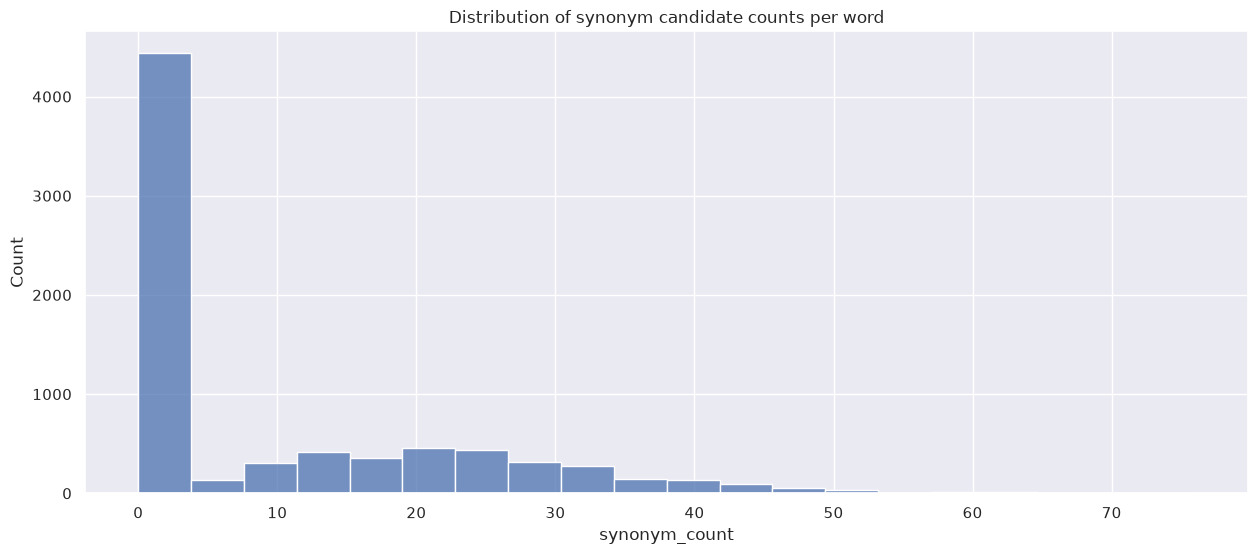

In [65]:
synonym_word_pos_df['synonym_count'] = synonym_word_pos_df['synonym_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)

plt.figure(figsize=(15,6))
sns.histplot(synonym_word_pos_df, x='synonym_count', bins=20)
plt.title('Distribution of synonym candidate counts per word')
plt.show()

In [ ]:
candidates_df = (synonym_word_pos_df[['word', 'pos', 'synonym_list']]
                  .explode('synonym_list')
                  .dropna(subset=['synonym_list'])
                  .rename(columns={'word': 'original_word', 'synonym_list': 'candidate'}))

candidates_with_cefr = candidates_df.merge(
    family1_word_cefr[['word', 'pos', 'cefr']].rename(columns={'word': 'candidate'}),
    on=['candidate', 'pos'], how='inner'
)

In [73]:
candidates_with_cefr.head()

,original_word,pos,candidate,cefr
0,advertisement,NOUN,advertising,B
1,advertisement,NOUN,announcement,B
2,advertisement,NOUN,publicity,B
3,advertisement,NOUN,ad,B
4,advertisement,NOUN,advert,B


In [90]:
candidates_with_cefr["pos"].value_counts()

pos
NOUN    17203
VERB     6509
ADJ      6492
ADV      2557
ADP       163
DET        33
PRON        5
Name: count, dtype: int64

In [82]:
print(f"Total words and associated POS: {candidates_with_cefr.shape[0]} words")
print(f"Total unique words: {candidates_with_cefr['original_word'].nunique()} words")

total_candidate_words_with_cefr = (candidates_with_cefr['candidate'].nunique()/family1_word_cefr['word'].nunique()) * 100
total_words_with_synonym_and_cefr = (candidates_with_cefr['original_word'].nunique()/family1_word_cefr['word'].nunique()) * 100
print(f"Total candidate/synonym words that have a CEFR level: {total_candidate_words_with_cefr:.2f}%")
print(f"Total words that have a synonym and a valid CEFR level: {total_words_with_synonym_and_cefr:.2f}%")

Total words and associated POS: 32962 words
Total unique words: 2901 words
Total candidate/synonym words that have a CEFR level: 77.27%
Total words that have a synonym and a valid CEFR level: 44.14%


## Family 3: "What English words exist, and what's their part of speech?"

> Part of Speech (POS) for available english words

In [88]:
family3_vocabulary = pd.read_json('../data/raw/all_english_words.json', typ='series').index.to_series(name='eng_words').reset_index(drop=True)
family3_tagged = pd.read_csv('../data/processed/all_english_words_tagged.csv',keep_default_na=False, na_values=[''])  # already exists -- create_word_dataset.py's output

print(f"raw vocabulary: {len(family3_vocabulary)} words")
print(f"already-tagged (processed): {len(family3_tagged)} words")
print(f"same word set: {set(family3_vocabulary) == set(family3_tagged['eng_words'])}")

family3_tagged['pos_tag'].value_counts()

raw vocabulary: 370100 words
already-tagged (processed): 370100 words
same word set: True


pos_tag
NOUN    279502
ADJ      39572
VERB     33804
ADV      17034
CONJ        96
DET         32
PRON        22
Name: count, dtype: int64

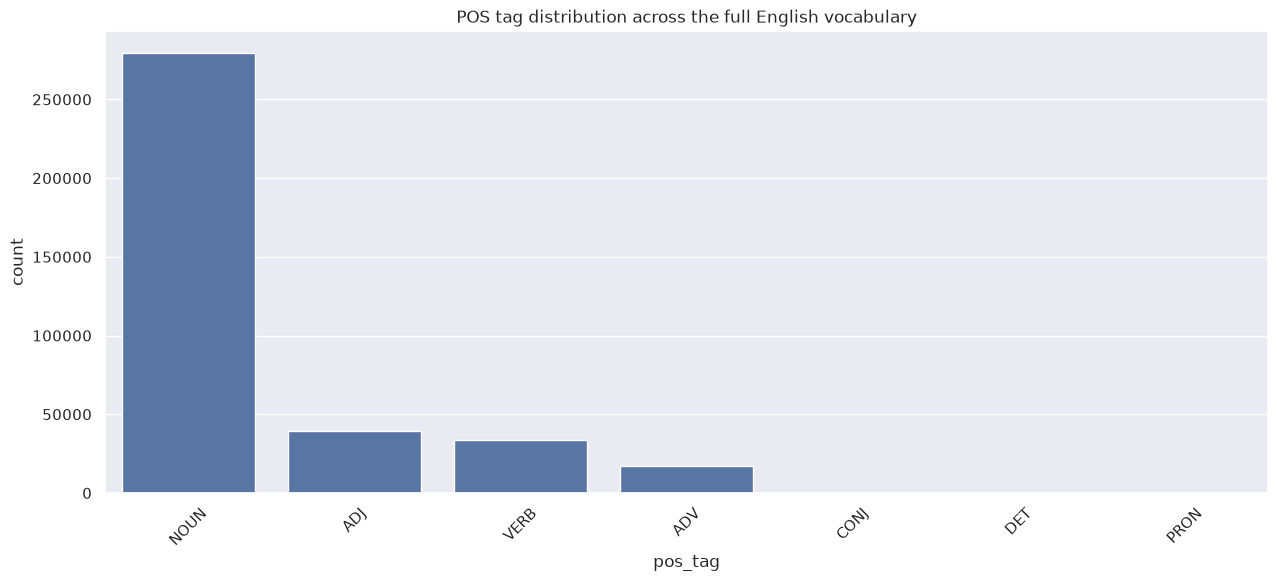

In [89]:
## Family 3
plt.figure(figsize=(15,6))
sns.countplot(data=family3_tagged, x='pos_tag', order=family3_tagged['pos_tag'].value_counts().index)
plt.title('POS tag distribution across the full English vocabulary')
plt.xticks(rotation=45)
plt.show()